### ***727723EUAI109 : SANJAY M***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

t = np.linspace(0, 6*np.pi, 300)
y = np.sin(t) + np.random.normal(0, 0.1, 300)

INPUT_STEPS, OUTPUT_STEPS = 10, 3

X, Y = [], []
for i in range(len(y) - INPUT_STEPS - OUTPUT_STEPS + 1):
    X.append(y[i:i+INPUT_STEPS])
    Y.append(y[i+INPUT_STEPS:i+INPUT_STEPS+OUTPUT_STEPS])

X, Y = np.array(X)[..., np.newaxis], np.array(Y)
print(f"X.shape: {X.shape}, Y.shape: {Y.shape}")

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = Y[:split], Y[split:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X.shape: (288, 10, 1), Y.shape: (288, 3)
Train: (230, 10, 1), Test: (58, 10, 1)


In [2]:
def build_model():
    model = Sequential([
        LSTM(64, input_shape=(INPUT_STEPS, 1)),
        Dense(32, activation='relu'),
        Dense(OUTPUT_STEPS)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_model()
model.summary()

es = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=150, batch_size=32,
                    validation_split=0.1, callbacks=[es], verbose=1)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,075 (74.51 KB)

 Trainable params: 19,075 (74.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.4541 - val_loss: 0.4687
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3158 - val_loss: 0.1944
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2005 - val_loss: 0.0475
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1359 - val_loss: 0.0412
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0971 - val_loss: 0.0332
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0765 - val_loss: 0.0409
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0702 - val_loss: 0.0296
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0639 - val_loss: 0.0266
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0578 - val_loss: 0.0268
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0516 - val_loss: 0.0280
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0453 - val_loss: 0.0250
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0384 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


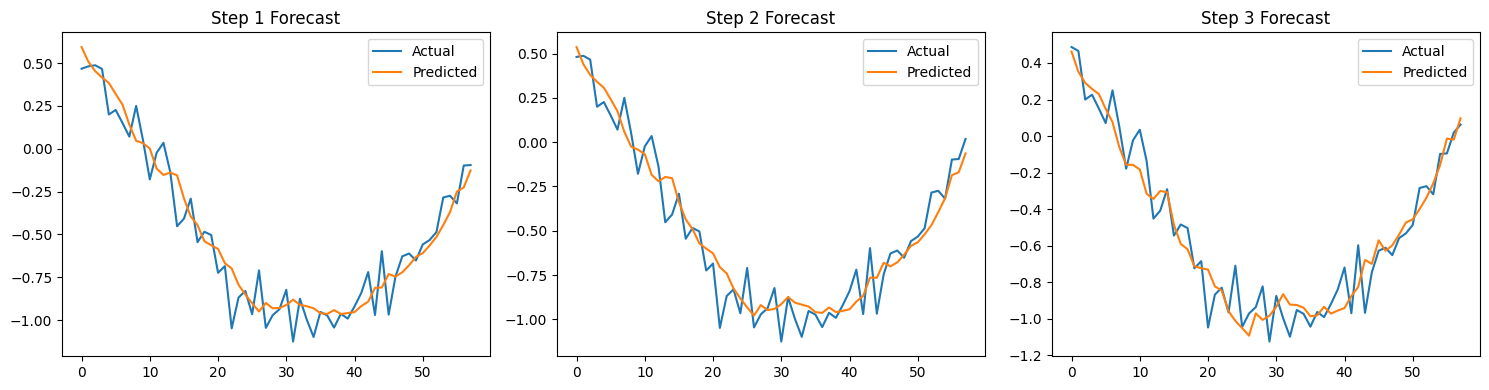

Step 1 MSE: 0.015703
Step 2 MSE: 0.014411
Step 3 MSE: 0.013973


In [3]:
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.plot(y_test[:, i], label='Actual')
    ax.plot(y_pred[:, i], label='Predicted')
    ax.set_title(f'Step {i+1} Forecast')
    ax.legend()
plt.tight_layout()
plt.show()

for i in range(OUTPUT_STEPS):
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    print(f"Step {i+1} MSE: {mse:.6f}")

In [4]:
def build_deep_model():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(INPUT_STEPS, 1)),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(OUTPUT_STEPS)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

deep_model = build_deep_model()
deep_model.summary()

es2 = EarlyStopping(patience=10, restore_best_weights=True)
deep_model.fit(X_train, y_train, epochs=150, batch_size=32,
               validation_split=0.1, callbacks=[es2], verbose=1)

y_pred_deep = deep_model.predict(X_test)

print("\n--- Shallow vs Deep MSE Comparison ---")
for i in range(OUTPUT_STEPS):
    mse_shallow = mean_squared_error(y_test[:, i], y_pred[:, i])
    mse_deep = mean_squared_error(y_test[:, i], y_pred_deep[:, i])
    print(f"Step {i+1} | Shallow MSE: {mse_shallow:.6f} | Deep MSE: {mse_deep:.6f}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,099 (203.51 KB)

 Trainable params: 52,099 (203.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.4439 - val_loss: 0.6863
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3064 - val_loss: 0.5333
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2161 - val_loss: 0.2094
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1215 - val_loss: 0.0477
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1325 - val_loss: 0.0346
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1114 - val_loss: 0.0671
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1013 - val_loss: 0.0440
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0914 - val_loss: 0.0333
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0863 - val_loss: 0.0325
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0765 - val_loss: 0.0312
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0646 - val_loss: 0.0276
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0529 - val_l